In [2]:
#1️⃣ Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
#2️⃣ Read and Display the Image
from google.colab import files
uploaded = files.upload()

Saving futbol.png to futbol.png


(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

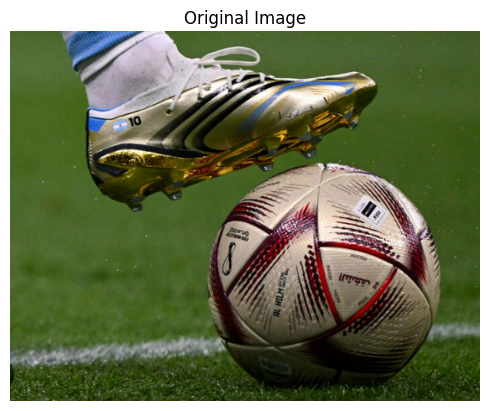

In [7]:
#loading the image
image = Image.open("futbol.png")
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

In [9]:
#Convert Image to NumPy Array
img_array = np.array(image)
print(img_array.shape)

(441, 560, 4)


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

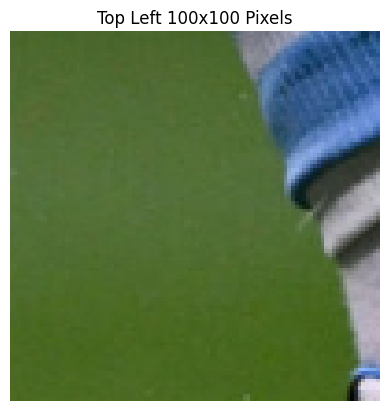

In [10]:
#Display Top-Left 100×100 Pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")

In [12]:
#Show RGB Color Channels, first seperating them
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

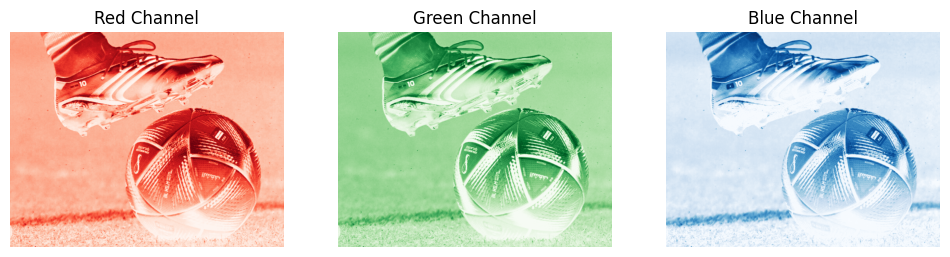

In [13]:
#now displaying them
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

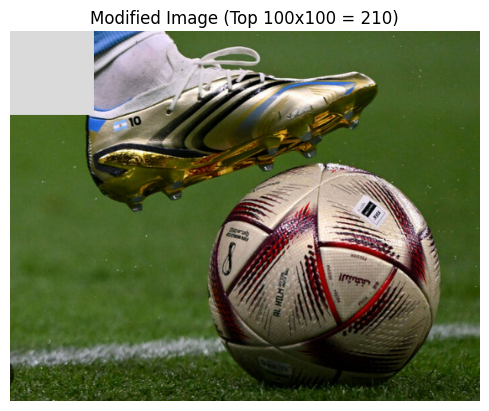

In [14]:
#Modify Top 100×100 Pixels to Value 210
modified = img_array.copy()

modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")

Exercise 2 – Grayscale Image Processing


(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

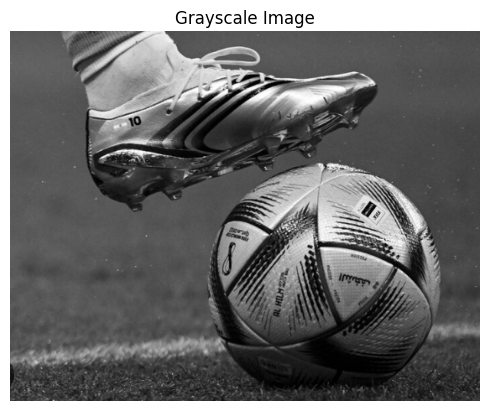

In [16]:
#Loading Grayscale Image
gray_image = Image.open("futbol.png").convert("L")

plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

In [17]:
#converting to numpy
gray = np.array(gray_image)

(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

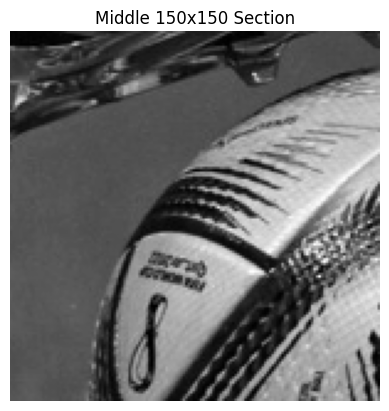

In [18]:
#Extract Middle 150 Pixels Section
h, w = gray.shape

center_h = h//2
center_w = w//2

middle = gray[center_h-75:center_h+75 , center_w-75:center_w+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")

(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

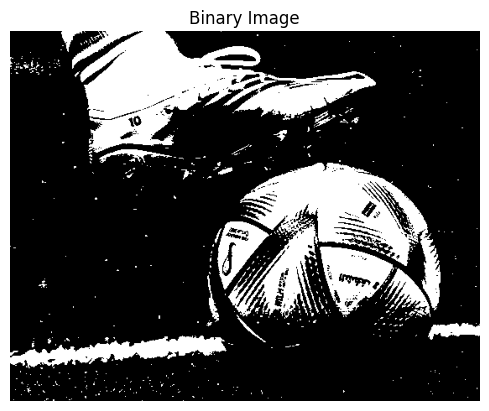

In [19]:
#Applying Threshold (Binary Image)
binary = gray.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

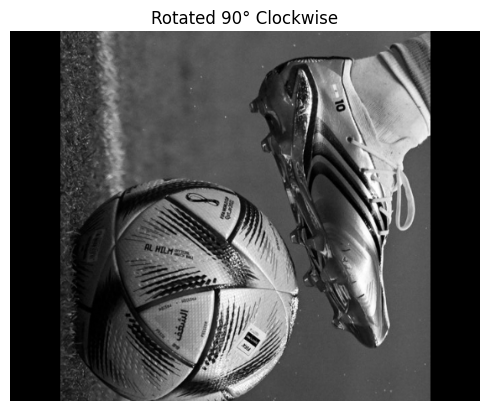

In [20]:
#Rotating Image 90° Clockwise
rotated = gray_image.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated 90° Clockwise")
plt.axis("off")

(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

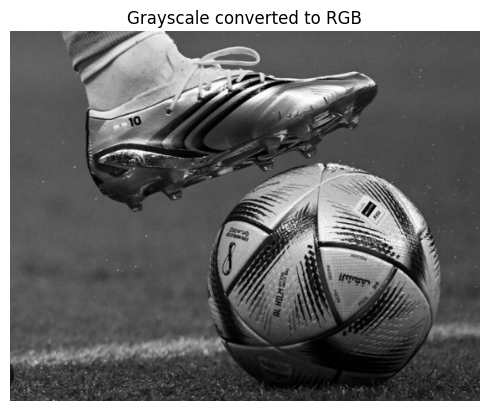

In [24]:
#Convert Grayscale to RGB
rgb_image = np.stack((gray,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale converted to RGB")
plt.axis("off")

Exercise 3 – PCA Image Compression (FROM SCRATCH)

(np.float64(-0.5), np.float64(559.5), np.float64(440.5), np.float64(-0.5))

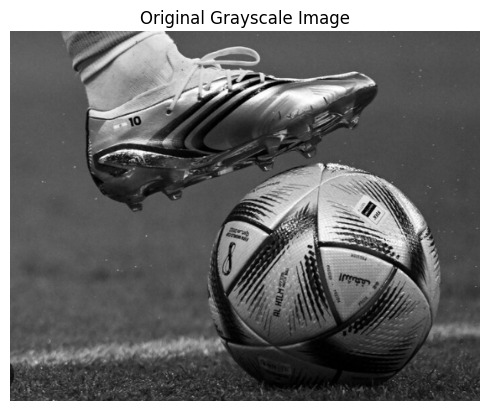

In [26]:
#Load Image and Convert to Grayscale
img = Image.open("futbol.png").convert("L")
img = np.array(img)

plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

In [27]:
#Standardize the Data (Centering)
mean = np.mean(img, axis=0)
centered = img - mean

In [29]:
#Covariance Matrix
cov_matrix = np.cov(centered, rowvar=False)

In [30]:
#Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [31]:
#Sort Eigenvalues in Descending Order
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:,sorted_index]

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


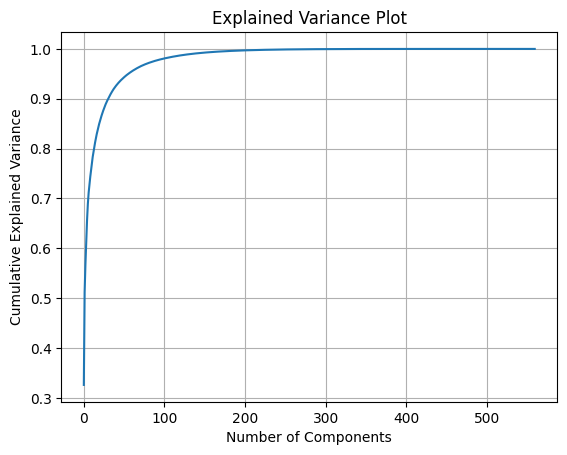

In [32]:
#Explained Variance Plot
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()

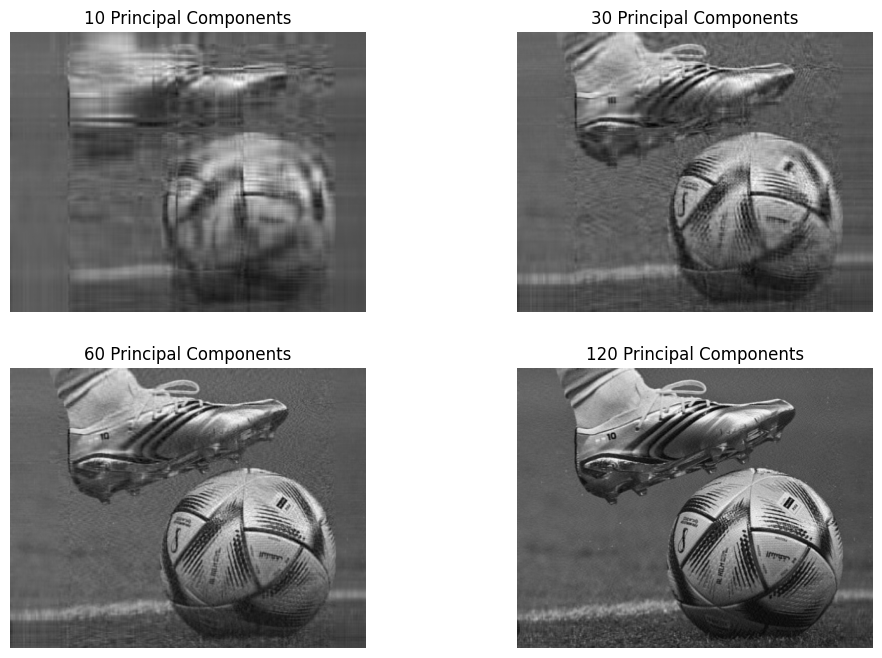

In [35]:
#Image Reconstruction Using Different Components
components = [10, 30, 60, 120]

plt.figure(figsize=(12,8))

for i,k in enumerate(components):

    eigenvector_subset = sorted_eigenvectors[:,:k]

    compressed = np.dot(centered, eigenvector_subset)

    reconstructed = np.dot(compressed, eigenvector_subset.T) + mean

    reconstructed = np.real(reconstructed)   # ⭐ FIX HERE

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Principal Components")
    plt.axis("off")

plt.show()